In [1]:
import face_recognition
import pandas as pd 
import scipy
from deepface import DeepFace
import cv2
import os
import numpy as np
import mediapipe as mp
from numpy.linalg import norm
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import csv
import base64
from io import BytesIO
from PIL import Image
import cv2
import csv
import time

# Data pre-processing

## IMDB-Wiki pre-processing

In [ ]:
imdb_mat = scipy.io.loadmat('imdb_crop/imdb.mat')
wiki_mat = scipy.io.loadmat('wiki_crop/wiki.mat')
columns = ["dob", "photo_taken", "full_path", "gender", "name", "face_location", "face_score", "second_face_score", "celeb_names", "celeb_id","source"]
imdb_instances = imdb_mat['imdb'][0][0][0].shape[1]
wiki_instances = wiki_mat['wiki'][0][0][0].shape[1]
imdb_df = pd.DataFrame(index = range(0,imdb_instances), columns = columns)
wiki_df = pd.DataFrame(index = range(0,wiki_instances), columns = columns)
 
for i in imdb_mat:
    if i == "imdb":
            current_array = imdb_mat[i][0][0]
            for j in range(len(current_array)):
                imdb_df[columns[j]] = pd.DataFrame(current_array[j][0])
                imdb_df["source"] = "imdb"

for i in wiki_mat:
    if i == "wiki":
            current_array = wiki_mat[i][0][0]
            for j in range(len(current_array)):
                wiki_df[columns[j]] = pd.DataFrame(current_array[j][0])
                wiki_df["source"] = "wiki"

df = pd.concat([imdb_df,wiki_df])
#remove pictures does not include face
df = df[df['face_score'] != -np.inf]
 
#some pictures include more than one face, remove them
df = df[df['second_face_score'].isna()]
 
#check threshold
df = df[df['face_score'] >= 3]

df = df.drop(columns= ["dob","photo_taken","name","celeb_names","celeb_id","second_face_score","face_score","face_location"])

def path(row):
    return row.source + "_crop/" + str(row.full_path).replace("[","").replace("]","").replace("'","")

df["full_path"] = df.apply(path,axis=1)

df = df.drop(columns= ["source"])

df = df.rename(columns = {"full_path": "image_id"})

In [ ]:
def prep_data_map(faces_directory):
    img_embedding_map = {}
    arrays = []
    c = 0
    for file in os.listdir(faces_directory):
        f = os.path.join(faces_directory, file)
        if os.path.isfile(f):
            embedding = extract_embedding(f,"Dlib")
            arrays.append(embedding)
            img_embedding_map[tuple(embedding)] = f
        c += 1
        if c == 1000:
            break
    data = np.vstack(arrays)
    return data, img_embedding_map
data, img_embedding_map = prep_data_map("img_align_celeba/img_align_celeba")
# fitting the data
km = KMeans(n_clusters=400).fit(data)

## CelebA

In [1]:
# PRE-PROCESSING FUNCTIONS

def not_small(row):
   file = row.image_id
   img = cv2.imread(file)
   if img.shape[0] > 100 and img.shape[1] > 100:
      return True
   return False

def is_gray(row):
    file = row.image_id
    img = cv2.imread(file)
    if len(img.shape) < 3: return True
    if img.shape[2]  == 1: return True
    b,g,r = img[:,:,0], img[:,:,1], img[:,:,2]
    if (b==g).all() and (b==r).all(): return True
    return False

def extract_face(row):
    file = row.image_id
    img = cv2.imread(file)
    faces = DeepFace.extract_faces(img,enforce_detection=False)
    if len(faces) > 1:
        return "REJECTED"
    if faces[0]["confidence"] < 5:
        return "REJECTED"
    return list(faces[0]["facial_area"].values())

def angle(row,face_mesh):
    file = row.image_id
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = face_mesh.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    img_h, img_w, img_c = image.shape
    face_3d = []
    face_2d = []
    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            for idx, lm in enumerate(face_landmarks.landmark):
                if idx == 33 or idx == 263 or idx == 1 or idx == 61 or idx == 291 or idx == 199:
                    if idx == 1:
                        nose_2d = (lm.x * img_w, lm.y * img_h)
                        nose_3d = (lm.x * img_w, lm.y * img_h, lm.z * 8000)
                    x, y = int(lm.x * img_w), int(lm.y * img_h)
                    face_2d.append([x, y])
                    face_3d.append([x, y, lm.z])       
            face_2d = np.array(face_2d, dtype=np.float64)
            face_3d = np.array(face_3d, dtype=np.float64)
            focal_length = 1 * img_w
            cam_matrix = np.array([ [focal_length, 0, img_h / 2],
                                    [0, focal_length, img_w / 2],
                                    [0, 0, 1]])
            dist_matrix = np.zeros((4, 1), dtype=np.float64)
            success, rot_vec, trans_vec = cv2.solvePnP(face_3d, face_2d, cam_matrix, dist_matrix)
            rmat, jac = cv2.Rodrigues(rot_vec)
            angles, mtxR, mtxQ, Qx, Qy, Qz = cv2.RQDecomp3x3(rmat)
            x = angles[0] * 360
            y = angles[1] * 360              
        return (x,y)

def is_face_fully_visible(row):
    area = str(row.area).replace("[","").replace("]","").split(",")
    f = row.image_id
    image = cv2.imread(f)
    face_coverage_threshold=0.1
    hair_extension_percentage=0.07
    x,y,w,h = int(area[0]),int(area[1]),int(area[2]),int(area[3])
    hair_extension = int(h * hair_extension_percentage)
    x -= hair_extension
    y -= hair_extension
    w += hair_extension * 2
    h += hair_extension * 2
    if x >= 0 and y >= 0 and (x + w) <= image.shape[1] and (y + h) <= image.shape[0]:
        bbox_area = w * h
        image_area = image.shape[0] * image.shape[1]
        coverage = bbox_area / image_area
        if coverage >= face_coverage_threshold:
            return True   
    return False

def is_frontal(row):
   angl = str(row.angle).replace("(","").replace(")","").split(",")
   if float(angl[0]) < 10  and float(angl[0]) > -10 and float(angl[1]) < 10  and float(angl[1]) > -10:
      return True
   return False

def extract_embedding(row):
    file = row.image_id
    return DeepFace.represent(file, model_name = "Facenet512")[0]["embedding"]

In [ ]:
# Assumptions:
#    - full path is stored in image_id
#    - column area [x,y,w,h]
#    - column angle (x,y)

def basic_clean(df,name,actions):
    if "size" in actions:
        mask = df.apply(not_small, axis=1)
        df = df[mask]
        df.to_csv(f"{name}/{name}_cp0.csv",index=False)
        print("cp0 done")
    if "gray" in actions:
        mask = df.apply(is_gray, axis=1)
        df = df[~mask]
        df.to_csv(f"{name}/{name}_cp1.csv",index=False)
        print("cp1 done")

# non-decisive cleaning
def advanced_clean(df,name,actions):
    if "frontal" in actions:
        mask = df.apply(is_frontal, axis=1)
        df = df[mask]
        df.to_csv(f"{name}/{name}_cp5.csv",index=False)
        print("cp5 done")
    if "visible" in actions:
        mask = df.apply(is_face_fully_visible, axis=1)
        df = df[mask]
        df.to_csv(f"{name}/{name}_cp6.csv",index=False)
        print("cp6 done")

def annotate(df,name,actions):
     if "angle" in actions:
        mp_face_mesh = mp.solutions.face_mesh
        face_mesh = mp_face_mesh.FaceMesh(min_detection_confidence=0.5, min_tracking_confidence=0.5)
        df["angle"] = df.apply(angle,args = (face_mesh,),axis=1)
        df = df.dropna()
        df.to_csv(f"{name}/{name}_cp2.csv",index=False)
        print("cp2 done")
     if "extract" in actions:
        df["area"] = df.apply(extract_face,axis = 1)
        df = df[df["area"] != "REJECTED"]
        df.to_csv(f"{name}/{name}_cp3.csv",index=False)
        print("cp3 done")
     if "embedding" in actions:
        df["embedding"] = df.apply(extract_embedding,axis=1)
        df.to_csv(f"{name}/{name}_cp4.csv",index=False)
        print("cp4 done")
    
def preprocess_pipeline(df,name,actions = ["size","gray","angle","extract","frontal","visible","embedding"]):
    print("Pre-processing ...")
    if "size" in actions or "gray" in actions:
        basic_clean(df,name,actions)
    if "angle" in actions or "extract" in actions or "embedding" in actions:
        annotate(df,name,actions)
    if "frontal" in actions or "visible" in actions:
        advanced_clean(df,name,actions)
   


In [ ]:
df = pd.read_csv("imdb-wiki/imdb-wiki_cp2.csv")
actions = ["extract","frontal","visible","embedding"]
preprocess_pipeline(df,"imdb-wiki")

Pre-processing ...


## MS-Celeb-1M

In [19]:
def is_gray(img):
    if len(img.mode) < 3: 
        return True
    if img.mode == 'L':
        return True
    r, g, b = img.split()
    if (r == g) and (r == b):
        return True
    return False

def extract_face(img):
    faces = DeepFace.extract_faces(img,enforce_detection=False)
    if len(faces) > 1:
        return "REJECTED"
    if faces[0]["confidence"] < 5:
        return "REJECTED"
    return list(faces[0]["facial_area"].values())

def extract_embedding(row):
    encoded_image_string = row[0]
    decoded_image = base64.b64decode(encoded_image_string)
    image = Image.open(BytesIO(decoded_image))
    cv2_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    return DeepFace.represent(cv2_image, model_name = "Facenet512")[0]["embedding"]

In [ ]:
batch_size = 500000

start = 5900000

output_file = "ms-celeb-1m.csv"

log_file = "log.txt"

with open(output_file, "a", newline='') as f:
    writer = csv.writer(f)
    
    chunks = pd.read_csv("MS-Celeb-1M/data/aligned_face_images/FaceImageCroppedWithAlignment.tsv",
                         sep="\t",
                         header=None,
                         chunksize=batch_size,
                         skiprows=range(1, start+1),
                         usecols=[6])
    
    for i, chunk in enumerate(chunks):
        batch_results = []
        start_time = time.time()

        for j in range(chunk.shape[0]):
            encoded_image_string = chunk.iloc[j, 0]
            decoded_image = base64.b64decode(encoded_image_string)
            image = Image.open(BytesIO(decoded_image))
            # size filter
            if image.size[0] > 100 and image.size[1] > 100:
                # gray filter
                if not is_gray(image):
                    # face filter + extract area
                    cv2_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
                    area = extract_face(cv2_image)
                    if area != "REJECTED":
                        # append the result to the batch list
                        batch_results.append((encoded_image_string, area))
        
        # Write the new data to the file
        writer.writerows(batch_results)
        
        with open(log_file,"w") as f:
            f.write("59\n" + str(i+1))
        
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Processed batch {i+1}: {elapsed_time}")

print("Processing complete.")

In [20]:
batch_size = 100000
start = 2 * batch_size
log_file = "log.txt"

chunks = pd.read_csv("ms-celeb-1m.csv",
                        chunksize=batch_size,
                        skiprows=range(1, start+1))

df = pd.DataFrame()
for i, chunk in enumerate(chunks):
    start_time = time.time()
    chunk["embedding"] = chunk.apply(extract_embedding,axis = 1) 
    with open(log_file,"w") as f:
        f.write(str(i+1))
    df = pd.concat([df,chunk])
    df.to_csv("faces2.csv")
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Processed batch {i+1}: {elapsed_time}")

print("Processing complete.")

Processed batch 1: 6792.08681845665
Processed batch 2: 7553.358214139938


: 

: 

In [21]:
df1 = pd.read_csv("faces1.csv",nrows=10,usecols=[1,2,3]).rename(columns = {"encoded_image_string":"image_id"})
df2 = pd.read_csv("faces2.csv",nrows=10,usecols=[1,2,3]).rename(columns = {"encoded_image_string":"image_id"})

concatenated_df = pd.concat([df1, df2], ignore_index=True)
df3 = pd.read_csv("faces.csv",nrows=10)

final_df = pd.concat([concatenated_df, df3], ignore_index=True)

final_df.to_csv("faces.csv",index = False)


## Recommendation

In [16]:
def cos_sim(row):
  embedding = str(row.embedding)
  B = np.array(embedding.replace("[","").replace("]","").split(",")).astype(float)
  A = input_embedding
  return np.dot(A,B)/(norm(A)*norm(B))
def recommend(input_image, df, n = 3):
    global input_embedding
    input_embedding = np.array(DeepFace.represent(input_image, model_name="Facenet512")[0]["embedding"])
    df["similarity"] = df.apply(cos_sim,axis = 1)
    df = df.sort_values(by="similarity",ascending=False)
    img = cv2.imread(input_image)
    plt.axis('off')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()
    for i in range(n):
      instance = df.iloc[i]
      try:
        full_path = instance['image_id']
        img = cv2.imread(full_path)
        plt.axis('off')
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.show()
      except:
        encoded_image_string = instance["encoded_image_string"]
        decoded_image = base64.b64decode(encoded_image_string)
        image = Image.open(BytesIO(decoded_image))
        display(image)
      similarity = instance['similarity']
      
      print(similarity)

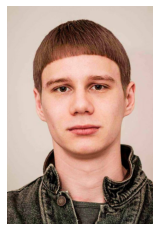

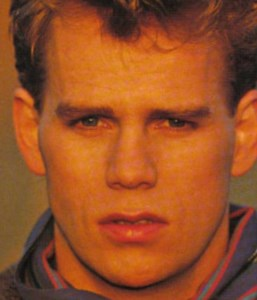

0.7216262021608612


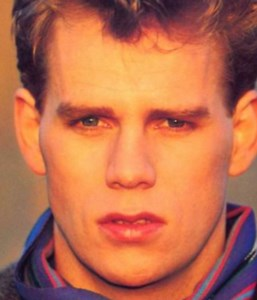

0.7152427571216013


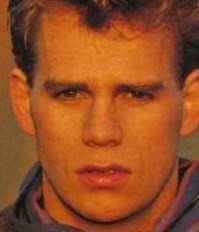

0.7137778509362993


In [17]:
df = pd.read_csv("faces1.csv")
input_image = "Experimentation/eval/bad-haircuts-men.jpg"
recommend(input_image, df)

# Expirementation

In [4]:
def cos_sim(A,B):
  return np.dot(A,B)/(norm(A)*norm(B))
def euclidean_sim(A, B):
    return 1 / (1 + np.linalg.norm(A - B))
def extract_embedding_experimentation(file,model,all = False):
  if model == "face_recognition":
    img = cv2.imread(file)
    embeddings = face_recognition.face_encodings(img)
  else: 
    dicts = DeepFace.represent(file, model_name = model,enforce_detection = False)
    embeddings = []
    for d in dicts:
      embeddings.append(np.array(d["embedding"]))
  if all == False:
      return embeddings[0]
  return embeddings

In [22]:
import time
models = [
  "face_recognition",
  "VGG-Face", 
  "Facenet", 
  "Facenet512", 
  "OpenFace", 
  "DeepFace", 
  "ArcFace", 
  "Dlib", 
  "SFace",
]
for model in models:
    s = time.time()
    embeddings = extract_embedding_experimentation("Experimentation/twins2.jpg",model,all=True)
    e = time.time()
    sim = cos_sim(embeddings[0],embeddings[1])
    print(model + ": " + str(sim) + " " + str(e-s))



face_recognition: 0.8960667099225429 0.5938928127288818
VGG-Face: 0.6433529209406925 0.6965832710266113
Facenet: 0.4570804899718381 0.30719614028930664
Facenet512: 0.35195238566579573 0.2551698684692383
OpenFace: 0.8196387722403946 0.23567461967468262
DeepFace: 0.7789555394871197 0.3650486469268799
ArcFace: 0.206350317011411 0.4126565456390381
Dlib: 0.9481577961504025 0.43024158477783203
SFace: 0.36134029744279583 0.12487339973449707


In [23]:
# finding the best model
baselines = ["Experimentation/neutral_face_women.jpg","Experimentation/neutral_face_men.jpg","Experimentation/front_angle.jpg"]
corrupt = ["Experimentation/expression_women.jpg","Experimentation/expression_men.jpg","Experimentation/different_angles.jpg"]
models = [
  "face_recognition",
  "VGG-Face", 
  "Facenet", 
  "Facenet512", 
  "OpenFace", 
  "DeepFace", 
  "ArcFace", 
  "Dlib", 
  "SFace",
]
for model in models:
    error = 0
    for i in range(len(baselines)):
      baseline = extract_embedding_experimentation(baselines[i],model)
      embeddings = extract_embedding_experimentation(corrupt[i],model, all=True)
      for embedding in embeddings:
        error += 1 - cos_sim(baseline,embedding)
    print(model + ": " + str(error/22))
    

face_recognition: 0.043111799630853154
VGG-Face: 0.17249692346720236
Facenet: 0.3174508649178388
Facenet512: 0.2596925536519141
OpenFace: 0.15634700485861883
DeepFace: 0.16210584175374393
ArcFace: 0.25565769953426437
Dlib: 0.03767231223091968
SFace: 0.332900478519676
